In [156]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [157]:
from hexgrid import *
# from hexplot import *
from hexstar import *

In [158]:
DIRECTIONS = (
    ( 1,  0),  # 0: E
    ( 1, -1),  # 1: SE
    ( 0, -1),  # 2: SW
    (-1,  0),  # 3: W
    (-1,  1),  # 4: NW
    ( 0,  1),  # 5: NE
)

In [166]:
from dataclasses import dataclass

@dataclass(frozen=True)
class DirectionInfo:
    s: int # distance from origin
    blockers: List[HexCoord] # HexCoords that must be open for this hex to be navigable

In [183]:
n = 4
DIRECTIONS_INFO = {}
directions = unique_direction_vectors_up_to_n(HexCoord(0,0),n)

for d in directions:
    DIRECTIONS_INFO[d] = DirectionInfo(
        s = euclid_center_distance(d, HexCoord(0,0)),
        blockers = hexes_in_between_solid(d, HexCoord(0,0))
    )
idx = 5
DIRECTIONS_INFO[directions[idx]].s

6.244997998398398

In [184]:
directions[idx]

HexCoord(q=1, r=3)

In [185]:
len(directions)

36

In [186]:
lengths = []
for i in range(200):
    lengths.append(len(unique_direction_vectors_up_to_n(HexCoord(0,0),i)))

print(lengths)

[0, 6, 12, 24, 36, 60, 72, 108, 132, 168, 192, 252, 276, 348, 384, 432, 480, 576, 612, 720, 768, 840, 900, 1032, 1080, 1200, 1272, 1380, 1452, 1620, 1668, 1848, 1944, 2064, 2160, 2304, 2376, 2592, 2700, 2844, 2940, 3180, 3252, 3504, 3624, 3768, 3900, 4176, 4272, 4524, 4644, 4836, 4980, 5292, 5400, 5640, 5784, 6000, 6168, 6516, 6612, 6972, 7152, 7368, 7560, 7848, 7968, 8364, 8556, 8820, 8964, 9384, 9528, 9960, 10176, 10416, 10632, 10992, 11136, 11604, 11796, 12120, 12360, 12852, 12996, 13380, 13632, 13968, 14208, 14736, 14880, 15312, 15576, 15936, 16212, 16644, 16836, 17412, 17664, 18024, 18264, 18864, 19056, 19668, 19956, 20244, 20556, 21192, 21408, 22056, 22296, 22728, 23016, 23688, 23904, 24432, 24768, 25200, 25548, 26124, 26316, 26976, 27336, 27816, 28176, 28776, 28992, 29748, 30132, 30636, 30924, 31704, 31944, 32592, 32988, 33420, 33804, 34620, 34884, 35712, 36000, 36552, 36972, 37692, 37980, 38652, 39084, 39588, 40020, 40908, 41148, 42048, 42480, 43056, 43416, 44136, 44424, 45360,

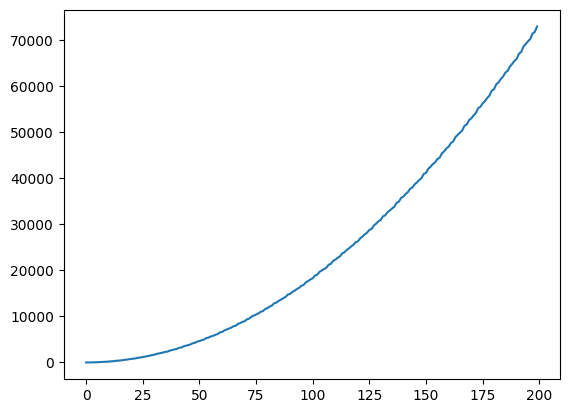

In [187]:
import matplotlib.pyplot as plt

plt.plot(lengths)

In [241]:
import math

def totient(n: int) -> int:
    """Euler's totient φ(n) via prime factorization (O(sqrt(n)) per n).

    Given n, the n-step parameter of Hex Star
    returns offset, the value to +/- the direction idx to get the candidate idxs
    """
    if n == 0:
        return 0
    if n <= 0:
        raise ValueError("n must be positive")
    result = n
    p = 2
    x = n
    while p * p <= x:
        if x % p == 0:
            while x % p == 0:
                x //= p
            result -= result // p
        p += 1 if p == 2 else 2  # small optimization: test 2 then odd primes
    if x > 1:
        result -= result // x
    return result

def value_at_index(x: int) -> int:
    """y(x) = 6 * sum_{k=1..x} φ(k), with y(0)=0."""
    if x < 0:
        raise ValueError("x must be non-negative")
    s = 0
    for k in range(1, x + 1):
        s += totient(k)
    return s

In [229]:
def circular_slice(seq, start, end):
    """
    Return a circular slice of seq for the half-open interval [start, end),
    wrapping around both ends as needed.

    Works like seq[start:end] but circular.
    """
    n = len(seq)
    if n == 0:
        return []

    length = end - start
    if length <= 0:
        return []

    start_mod = start % n
    end_mod = (start_mod + length) % n

    if length >= n:
        # If you ask for >= one full revolution, define your preference.
        # Here: return exactly 'length' elements by cycling.
        return [seq[(start + i) % n] for i in range(length)]

    if start_mod < end_mod:
        return list(seq[start_mod:end_mod])
    else:
        # wraps across the end
        return list(seq[start_mod:]) + list(seq[:end_mod])

In [245]:
[value_at_index(n) for n in range(15)]

[0, 1, 2, 4, 6, 10, 12, 18, 22, 28, 32, 42, 46, 58, 64]

In [243]:
offset = 6
idx = 0
value_at_index(12)


46

In [ ]:
5 -- offset:10
4 -- offset:6
3 -- offset:4
2 -- offset:2
1 -- offset:1